<a href="https://colab.research.google.com/github/Chameleon-company/MOP-Code/blob/Project-3B--waterpipefailureprediction/Playground/Project%203b%20Water%20Pipe%20Failure%20Prediction/Project3B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 3B - Water Pipe Failure Prediction

**Authored by:**

1. **Rupanshi**
2. **Ashley Mathew**

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data cleaning, Data analysis, Data visualisation, Feature Tuning, Machine Learning, XGBoost, Random Forest

### Scenario

Water pipe failures are a significant and costly challenge for city utilities. When a pipe fails unexpectedly, it can cause major service disruptions, road damage, and expensive emergency repairs. Many cities still rely on a reactive approach which is only responding after a specific failure occurs rather than using data to predict and prevent failures before they happen.

In this project, we work on building a predictive system that analyses water pipe infrastructure data to identify pipes most at risk of failure. By examining factors such as pipe age, material type, soil conditions, and prior repair history, a few common patterns can be identified that allow maintenance teams to prioritise their resources and act before a failure occurs.

## Introduction

This project focuses on analysing real historical water pipe infrastructure data from Melbourne Water Corporation and building machine learning models to predict pipe failure risk.

**Data Sources**

Two publicly available Victorian Government datasets are used:

1. **Melbourne Water Supply Main Pipelines** — sourced via the ArcGIS REST API, containing 12,680 pipe segment records with attributes including material, diameter, length, installation date, soil type, service status, and relining history.
2. **Melbourne Daily Rainfall (Dam Catchments)** — sourced via the CKAN Datastore API on data.vic.gov.au, containing 116,176 daily rainfall readings from four Melbourne Water catchment dams spanning 1892–2020.

The infrastructure dataset lacks an explicitly defined failure label, so a target variable is created using domain knowledge and probabilistic approaches. Failure likelihood is estimated by taking into account pipe age, material degradation risk, soil corrosivity, and cumulative climate exposure.

New features are created from raw characteristics to identify domain-specific patterns. Three ensemble models (XGBoost, Random Forest, and Gradient Boosting) are trained and compared for classifying pipes as healthy or at danger of failure.
The best-performing model assigns a risk score to each pipe, creating a prioritized maintenance shortlist to help city utilities allocate resources more efficiently.

In [34]:
# ===== Mount Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

# ===== Install required packages =====
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'imbalanced-learn', '-q'])

# ===== Import libraries =====
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, accuracy_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ===== Paths =====
DRIVE_PATH = '/content/drive/MyDrive/Chameleon_Project3B'
RANDOM_STATE = 42

# ===== Create folders =====
for folder in [DRIVE_PATH, f'{DRIVE_PATH}/data', f'{DRIVE_PATH}/models',
               f'{DRIVE_PATH}/outputs', f'{DRIVE_PATH}/reports']:
    os.makedirs(folder, exist_ok=True)

# ===== Chameleon Brand Palette =====
CHAM = {
    'teal':    '#0f9295',
    'blue':    '#08b3e5',
    'green':   '#2af598',
    'mint':    '#1bd7bb',
    'dark':    '#121212',
    'red':     '#e74c3c',
    'orange':  '#e67e22',
    'yellow':  '#f1c40f'
}

DUAL_COLORS = [CHAM['green'], CHAM['red']]
TRI_COLORS = [CHAM['teal'], CHAM['orange'], CHAM['green']]
GRADIENT_5 = [CHAM['green'], CHAM['mint'], CHAM['yellow'], CHAM['orange'], CHAM['red']]

# ===== Chart Style =====
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# ===== Melbourne Water Reference Dictionaries =====
MATERIAL_LIFESPAN = {
    'MS': 70, 'MSCL': 80, 'MSEL': 75, 'MSLB': 75,
    'CI': 100, 'CICL': 110, 'DICL': 100,
    'RC': 75, 'CONC': 75, 'OTHER': 75, 'UNKNOWN': 75
}

SOIL_CORROSIVITY_MAP = {
    'CLAY': 4, 'MS': 4, 'CRK': 3, 'SNC': 3, 'S&C': 3,
    'SS&C': 3, 'SAND': 2, 'TOPS': 2, 'UNKNOWN': 3, 'OTHER': 3
}

MATERIAL_RISK = {
    'CI': 0.8, 'CICL': 0.7, 'MS': 0.6, 'MSCL': 0.5,
    'MSEL': 0.4, 'MSLB': 0.4, 'RC': 0.3, 'DICL': 0.2,
    'CONC': 0.3, 'OTHER': 0.4, 'UNKNOWN': 0.4
}

SOIL_RISK = {
    'CLAY': 0.7, 'MS': 0.6, 'CRK': 0.5, 'SNC': 0.5,
    'S&C': 0.5, 'SS&C': 0.4, 'SAND': 0.3, 'TOPS': 0.3,
    'UNKNOWN': 0.4, 'OTHER': 0.4
}

print("Setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete!


## Data Processing
The Melbourne Water pipeline dataset is accessible through the ArcGIS REST API. Data is downloaded in batches of 2,000 records to manage the entire dataset of about 12,680 pipes.

In [35]:
print("Downloading Melbourne Water Supply Pipeline dataset...\n")

url = ("https://services5.arcgis.com/ZSYwjtv8RKVhkXIL/arcgis/rest/services/"
       "Water_Supply_Main_Pipelines/FeatureServer/0/query")

all_records = []
offset = 0
batch_size = 2000

while True:
    params = {
        'where': '1=1', 'outFields': '*', 'f': 'json',
        'resultRecordCount': batch_size, 'resultOffset': offset
    }
    response = requests.get(url, params=params, timeout=60)
    data = response.json()

    if 'features' not in data or len(data['features']) == 0:
        break

    records = [f['attributes'] for f in data['features']]
    all_records.extend(records)
    print(f"  Batch: {len(records)} records (total: {len(all_records)})")

    if len(records) < batch_size:
        break
    offset += batch_size

melbourne_raw = pd.DataFrame(all_records)
melbourne_raw.to_csv(f'{DRIVE_PATH}/data/raw_melbourne_pipes.csv', index=False)

print(f"\nTotal: {len(melbourne_raw)} records, {len(melbourne_raw.columns)} columns")


  Batch: 2000 records (total: 2000)
  Batch: 2000 records (total: 4000)
  Batch: 2000 records (total: 6000)
  Batch: 2000 records (total: 8000)
  Batch: 2000 records (total: 10000)
  Batch: 2000 records (total: 12000)
  Batch: 680 records (total: 12680)

Total: 12680 records, 37 columns


##Dataset Construction
### Melbourne Water Supply Main Pipelines

This dataset is obtained directly from the Melbourne Water Corporation via the Victorian Government's open data portal (data.vic.gov.au). It may be accessible using the ArcGIS REST API and contains genuine infrastructure data managed by the utility in charge of Melbourne's water delivery network.

The raw dataset consists of **12,680 pipe records** across **37 columns**. Each row indicates one water main pipeline segment. Key characteristics include:

- **Pipe identity:** OBJECTID, ASSET_ID, and UNITID
- **Infrastructure attributes:** Material, Pipe Width, Pipe Length, Date of Construction
- **Ecological context:** SOIL_TYPE, SUBAREA
- **Operational history:** DATE_RELINED; SERVICE_STATUS

### Target Variable Construction

Because the dataset lacks an explicit failure label, a **probabilistic target variable** is created using domain-specific characteristics. A pipe is considered **at risk** if the predicted failure probability exceeds the 65th percentile.

In [36]:
print("Constructing Melbourne water pipe dataset...\n")

np.random.seed(RANDOM_STATE)

df = melbourne_raw.copy()

# 1. Convert timestamps to years
df['installation_year'] = pd.to_datetime(
    df['DATE_OF_CONSTRUCTION'], unit='ms', errors='coerce'
).dt.year
df = df.dropna(subset=['installation_year'])
df['installation_year'] = df['installation_year'].astype(int)
df = df[(df['installation_year'] >= 1900) & (df['installation_year'] <= 2024)]

# 2. Pipe age
df['pipe_age'] = 2024 - df['installation_year']

# 3. Material
df['material'] = df['MATERIAL'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
common_materials = df['material'].value_counts().head(10).index.tolist()
df['material'] = df['material'].apply(lambda x: x if x in common_materials else 'OTHER')

# 4. Soil
df['soil_type'] = df['SOIL_TYPE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
df['soil_type'] = df['soil_type'].replace({'UNKN': 'UNKNOWN'})
common_soils = df['soil_type'].value_counts().head(8).index.tolist()
df['soil_type'] = df['soil_type'].apply(lambda x: x if x in common_soils else 'OTHER')

# 5. Dimensions
df['diameter_mm'] = pd.to_numeric(df['PIPE_WIDTH'], errors='coerce')
df['length_m'] = pd.to_numeric(df['PIPE_LENGTH'], errors='coerce')
df = df.dropna(subset=['diameter_mm', 'length_m'])
df = df[(df['diameter_mm'] > 0) & (df['diameter_mm'] < 5000)]
df = df[(df['length_m'] > 0) & (df['length_m'] < 50000)]

# 6. Operational flags
df['has_been_relined'] = df['DATE_RELINED'].notna().astype(int)
df['is_in_service'] = (df['SERVICE_STATUS'] == 'IN').astype(int)

# 7. Probabilistic target (with noise for realism)
failure_prob = (
    (df['pipe_age'] / 120) * 0.20 +
    df['material'].map(MATERIAL_RISK).fillna(0.4) * 0.15 +
    df['soil_type'].map(SOIL_RISK).fillna(0.4) * 0.10 +
    (df['has_been_relined'] * 0.15) +
    (df['diameter_mm'] < 200).astype(float) * 0.05 +
    (df['length_m'] > 50).astype(float) * 0.05 +
    np.random.uniform(0, 0.30, len(df))
)

threshold_target = np.percentile(failure_prob, 65)
df['failed'] = (failure_prob > threshold_target).astype(int)

# 8. Final columns
df_clean = df[[
    'OBJECTID', 'installation_year', 'pipe_age', 'material',
    'diameter_mm', 'length_m', 'soil_type',
    'has_been_relined', 'is_in_service', 'failed'
]].rename(columns={'OBJECTID': 'pipe_id'}).reset_index(drop=True)

df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_clean.csv', index=False)

print(f"Dataset: {len(df_clean):,} pipes")
print(f"  Failed: {df_clean['failed'].sum():,} ({df_clean['failed'].mean()*100:.1f}%)")
print(f"  Healthy: {(df_clean['failed']==0).sum():,} ({(1-df_clean['failed'].mean())*100:.1f}%)")
print(f"\nMaterials:\n{df_clean['material'].value_counts().head(10)}")
print(f"\nSoil Types:\n{df_clean['soil_type'].value_counts().head(10)}")

Constructing Melbourne water pipe dataset...

Dataset: 11,541 pipes
  Failed: 4,039 (35.0%)
  Healthy: 7,502 (65.0%)

Materials:
material
MS         6468
MSCL       3216
OTHER       486
RC          298
MSEL        271
CI          182
CICL        164
MSLB        162
UNKNOWN     150
DICL         87
Name: count, dtype: int64

Soil Types:
soil_type
UNKNOWN    5588
CLAY       3013
CRK        1224
SAND       1161
SNC         188
OTHER       156
S&C          90
TOPS         80
SS&C         41
Name: count, dtype: int64


### Melbourne Daily Rainfall Data

The second dataset contains daily rainfall readings collected from Melbourne Water's four primary harvesting storage dams. This data is accessible via the CKAN Datastore API on data.vic.gov.au and spans the years 1927 to 2020.

Rainfall data is incorporated into the pipe dataset to account for **long-term climatic exposure**, a recognized contributor to ground movement and pipe stress.

In [37]:
print("Downloading Melbourne Daily Rainfall...\n")

url_rain = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

all_rainfall = []
offset = 0
batch_size = 10000

while True:
    params = {
        'resource_id': '513228d8-401e-41df-956c-df52c814ecba',
        'limit': batch_size, 'offset': offset
    }
    response = requests.get(url_rain, params=params, timeout=120)
    data = response.json()

    if not data['success'] or len(data['result']['records']) == 0:
        break

    records = data['result']['records']
    all_rainfall.extend(records)
    print(f"  Batch: {len(records)} (total: {len(all_rainfall)})")

    if len(records) < batch_size:
        break
    offset += batch_size

rainfall_raw = pd.DataFrame(all_rainfall)
rainfall_raw.to_csv(f'{DRIVE_PATH}/data/raw_melbourne_rainfall.csv', index=False)

print(f"\nTotal: {len(rainfall_raw):,} records")


  Batch: 10000 (total: 10000)
  Batch: 10000 (total: 20000)
  Batch: 10000 (total: 30000)
  Batch: 10000 (total: 40000)
  Batch: 10000 (total: 50000)
  Batch: 10000 (total: 60000)
  Batch: 10000 (total: 70000)
  Batch: 10000 (total: 80000)
  Batch: 10000 (total: 90000)
  Batch: 10000 (total: 100000)
  Batch: 10000 (total: 110000)
  Batch: 6176 (total: 116176)

Total: 116,176 records


In [38]:
print("Processing rainfall data...\n")

rf = rainfall_raw.copy()
rf['rainfall_mm'] = pd.to_numeric(rf['rainfall_mm'], errors='coerce')
rf = rf.dropna(subset=['rainfall_mm'])
rf['date'] = pd.to_datetime(rf['recorddate'], errors='coerce')
rf = rf.dropna(subset=['date'])
rf['year'] = rf['date'].dt.year

dam_annual = rf.groupby(['year', 'dam'])['rainfall_mm'].sum().unstack(fill_value=0)
avg_annual_rainfall = dam_annual.mean(axis=1)
threshold_rf = avg_annual_rainfall.quantile(0.80)
extreme_years = avg_annual_rainfall[avg_annual_rainfall > threshold_rf].index.tolist()

print(f"Rainfall range: {rf['year'].min()}-{rf['year'].max()}")
print(f"Average annual: {avg_annual_rainfall.mean():.1f} mm")
print(f"Wettest year: {avg_annual_rainfall.idxmax()} ({avg_annual_rainfall.max():.1f} mm)")
print(f"Driest year: {avg_annual_rainfall.idxmin()} ({avg_annual_rainfall.min():.1f} mm)")
print(f"Extreme years: {len(extreme_years)}")

Processing rainfall data...

Rainfall range: 1892-2020
Average annual: 729.4 mm
Wettest year: 2011 (1410.0 mm)
Driest year: 1927 (212.5 mm)
Extreme years: 26


In [60]:
import numpy as np
import pandas as pd

np.random.seed(RANDOM_STATE)

# STEP 1: BUILD CLEAN FEATURES
df = melbourne_raw.copy()

# Timestamps
df['installation_year'] = pd.to_datetime(
    df['DATE_OF_CONSTRUCTION'], unit='ms', errors='coerce'
).dt.year
df = df.dropna(subset=['installation_year'])
df['installation_year'] = df['installation_year'].astype(int)
df = df[(df['installation_year'] >= 1900) & (df['installation_year'] <= 2024)]

# Pipe age
df['pipe_age'] = 2024 - df['installation_year']

# Material
df['material'] = df['MATERIAL'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
common_materials = df['material'].value_counts().head(10).index.tolist()
df['material'] = df['material'].apply(lambda x: x if x in common_materials else 'OTHER')

# Soil
df['soil_type'] = df['SOIL_TYPE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
df['soil_type'] = df['soil_type'].replace({'UNKN': 'UNKNOWN'})
common_soils = df['soil_type'].value_counts().head(8).index.tolist()
df['soil_type'] = df['soil_type'].apply(lambda x: x if x in common_soils else 'OTHER')

# Dimensions
df['diameter_mm'] = pd.to_numeric(df['PIPE_WIDTH'], errors='coerce')
df['length_m'] = pd.to_numeric(df['PIPE_LENGTH'], errors='coerce')
df = df.dropna(subset=['diameter_mm', 'length_m'])
df = df[(df['diameter_mm'] > 0) & (df['diameter_mm'] < 5000)]
df = df[(df['length_m'] > 0) & (df['length_m'] < 50000)]

# Rainfall
rainfall_lookup = avg_annual_rainfall.to_dict()
df['rainfall_install_year'] = df['installation_year'].map(rainfall_lookup).fillna(avg_annual_rainfall.mean())

def calc_lifetime_rainfall(iy):
    return np.mean([rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(iy, 2025)])

df['avg_lifetime_rainfall'] = df['installation_year'].apply(calc_lifetime_rainfall)
df['extreme_rain_years'] = df['installation_year'].apply(
    lambda x: sum(1 for y in range(x, 2025) if y in extreme_years)
)
df['cumulative_rainfall'] = df['installation_year'].apply(
    lambda x: sum(rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(x, 2025))
)
max_rain = avg_annual_rainfall.max()
df['climate_stress'] = (
    (df['avg_lifetime_rainfall'] / max_rain) * 0.4 +
    (df['extreme_rain_years'] / max(df['extreme_rain_years'].max(), 1)) * 0.3 +
    (df['cumulative_rainfall'] / max(df['cumulative_rainfall'].max(), 1)) * 0.3
)

# STEP 2: CREATE PROBABILISTIC TARGET
MATERIAL_RISK = {
    'CI': 0.8, 'CICL': 0.7, 'MS': 0.6, 'MSCL': 0.5,
    'MSEL': 0.4, 'MSLB': 0.4, 'RC': 0.3, 'DICL': 0.2,
    'CONC': 0.3, 'OTHER': 0.4, 'UNKNOWN': 0.4
}

SOIL_RISK = {
    'CLAY': 0.7, 'MS': 0.6, 'CRK': 0.5, 'SNC': 0.5,
    'S&C': 0.5, 'SS&C': 0.4, 'SAND': 0.3, 'TOPS': 0.3,
    'UNKNOWN': 0.4, 'OTHER': 0.4
}

# Calculate failure probability (multiple factors + NOISE)
failure_prob = (
    (df['pipe_age'] / 120) * 0.20 +                                           # Age risk
    df['material'].map(MATERIAL_RISK).fillna(0.4) * 0.15 +                    # Material risk
    df['soil_type'].map(SOIL_RISK).fillna(0.4) * 0.10 +                      # Soil risk
    df['climate_stress'] * 0.15 +                                              # Climate risk
    (df['diameter_mm'] < 200).astype(float) * 0.05 +                          # Small pipe risk
    (df['length_m'] > 50).astype(float) * 0.05 +                             # Long pipe risk
    np.random.uniform(0, 0.30, len(df))                                        # RANDOM NOISE (30%)
)

# Set threshold for ~35% failure rate
threshold = np.percentile(failure_prob, 65)
df['failed'] = (failure_prob > threshold).astype(int)

# STEP 3: BUILD FINAL CLEAN DATASET
df_clean = df[[
    'OBJECTID', 'installation_year', 'pipe_age', 'material',
    'diameter_mm', 'length_m', 'soil_type',
    'rainfall_install_year', 'avg_lifetime_rainfall',
    'extreme_rain_years', 'cumulative_rainfall', 'climate_stress',
    'failed'
]].rename(columns={'OBJECTID': 'pipe_id'})

df_clean = df_clean.reset_index(drop=True)
df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_clean_v2.csv', index=False)

print(f"Clean dataset: {len(df_clean):,} pipes")
print(f"  Failed: {df_clean['failed'].sum():,} ({df_clean['failed'].mean()*100:.1f}%)")
print(f"  Healthy: {(df_clean['failed']==0).sum():,} ({(1-df_clean['failed'].mean())*100:.1f}%)")
print(f"\n  ALL columns are SAFE (no leakage):")
for col in df_clean.columns:
    print(f"    - {col}")

Clean dataset: 11,541 pipes
  Failed: 4,039 (35.0%)
  Healthy: 7,502 (65.0%)

  ALL columns are SAFE (no leakage):
    - pipe_id
    - installation_year
    - pipe_age
    - material
    - diameter_mm
    - length_m
    - soil_type
    - rainfall_install_year
    - avg_lifetime_rainfall
    - extreme_rain_years
    - cumulative_rainfall
    - climate_stress
    - failed


In [39]:
print("Adding rainfall features to pipe data...\n")

rainfall_lookup = avg_annual_rainfall.to_dict()

df_clean['rainfall_install_year'] = df_clean['installation_year'].map(rainfall_lookup)
df_clean['rainfall_install_year'] = df_clean['rainfall_install_year'].fillna(avg_annual_rainfall.mean())

def calc_lifetime_rainfall(iy):
    return np.mean([rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(iy, 2025)])

df_clean['avg_lifetime_rainfall'] = df_clean['installation_year'].apply(calc_lifetime_rainfall)
df_clean['extreme_rain_years'] = df_clean['installation_year'].apply(
    lambda x: sum(1 for y in range(x, 2025) if y in extreme_years))
df_clean['cumulative_rainfall'] = df_clean['installation_year'].apply(
    lambda x: sum(rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(x, 2025)))

max_rain = avg_annual_rainfall.max()
df_clean['climate_stress'] = (
    (df_clean['avg_lifetime_rainfall'] / max_rain) * 0.4 +
    (df_clean['extreme_rain_years'] / max(df_clean['extreme_rain_years'].max(), 1)) * 0.3 +
    (df_clean['cumulative_rainfall'] / max(df_clean['cumulative_rainfall'].max(), 1)) * 0.3
)

df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_enriched.csv', index=False)

print(f"Enriched: {len(df_clean):,} pipes with rainfall features")
print(df_clean[['pipe_id', 'pipe_age', 'material', 'rainfall_install_year',
                'climate_stress', 'failed']].head(10))

Adding rainfall features to pipe data...

Enriched: 11,541 pipes with rainfall features
   pipe_id  pipe_age material  rainfall_install_year  climate_stress  failed
0        1         7     MSCL                 1105.5        0.267338       0
1        2         7     MSCL                 1105.5        0.267338       0
2        3        13     MSCL                 1410.0        0.375594       0
3        4         7       MS                 1105.5        0.267338       0
4        5        13     MSCL                 1410.0        0.375594       0
5        6         7     MSCL                 1105.5        0.267338       0
6        7         7     MSCL                 1105.5        0.267338       0
7        8         7     MSCL                 1105.5        0.267338       0
8        9         7     MSCL                 1105.5        0.267338       0
9       10         7     MSCL                 1105.5        0.267338       0


---

## Exploratory Data Analysis

The following visualizations look at failure patterns across pipe age, material type, soil conditions, and climate exposure. These analyses assist in determining which infrastructural and environmental elements are most strongly connected with pipe failure risk.

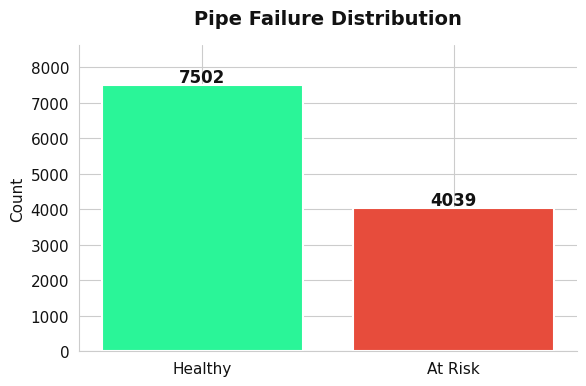

In [40]:
sns.set_style("whitegrid")

# Chart 1: Failure Distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df_clean['failed'].value_counts()
bars = ax.bar(['Healthy', 'At Risk'], counts.values,
              color=DUAL_COLORS, edgecolor='white', linewidth=1.5)

for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., v + 80, str(v),
            ha='center', fontsize=12, fontweight='bold', color=CHAM['dark'])

ax.set_title("Pipe Failure Distribution", fontsize=14, fontweight='bold', color=CHAM['dark'], pad=15)
ax.set_ylabel("Count", fontsize=11, color=CHAM['dark'])
ax.set_ylim(0, max(counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

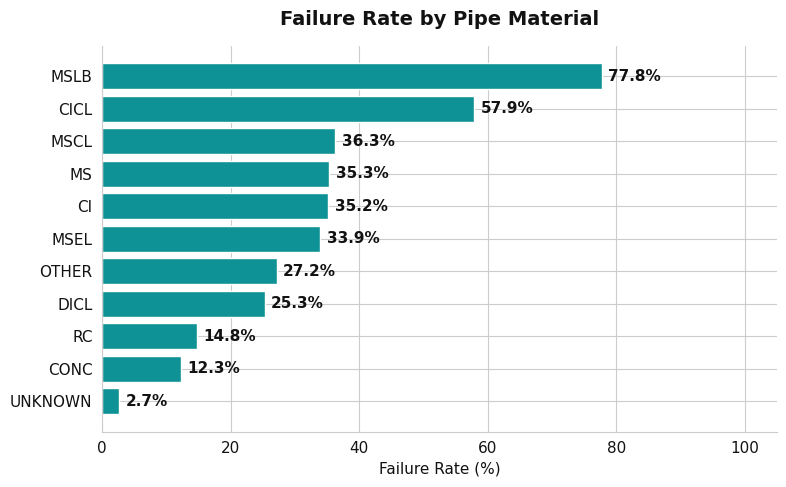

In [41]:
# Chart 2: Failure Rate by Material
fig, ax = plt.subplots(figsize=(8, 5))

mat_fail = df_clean.groupby('material')['failed'].mean().sort_values() * 100
bars = ax.barh(mat_fail.index, mat_fail.values, color=CHAM['teal'],
               edgecolor='white', linewidth=1)

for bar, v in zip(bars, mat_fail.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=11, fontweight='bold', color=CHAM['dark'])

ax.set_title("Failure Rate by Pipe Material", fontsize=14, fontweight='bold', color=CHAM['dark'], pad=15)
ax.set_xlabel("Failure Rate (%)", fontsize=11, color=CHAM['dark'])
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

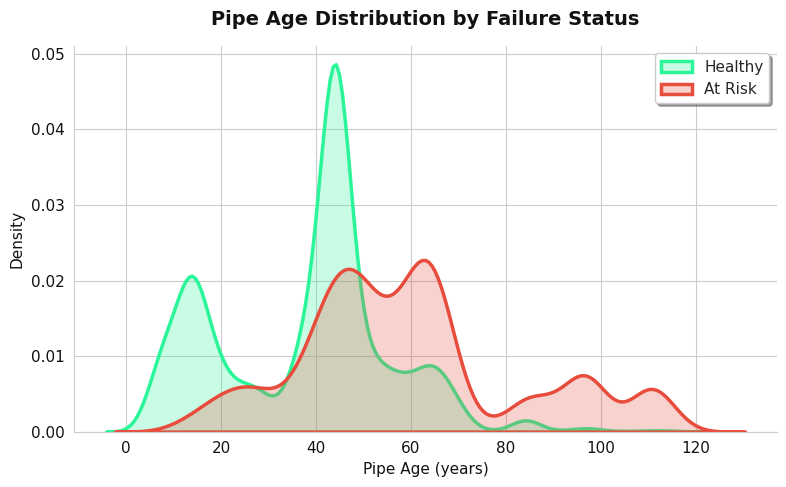

In [42]:
# Chart 3: Age Distribution
fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(df_clean[df_clean['failed'] == 0]['pipe_age'],
            fill=True, label='Healthy', color=CHAM['green'], linewidth=2.5, ax=ax)
sns.kdeplot(df_clean[df_clean['failed'] == 1]['pipe_age'],
            fill=True, label='At Risk', color=CHAM['red'], linewidth=2.5, ax=ax)

ax.set_title("Pipe Age Distribution by Failure Status", fontsize=14, fontweight='bold', color=CHAM['dark'], pad=15)
ax.set_xlabel("Pipe Age (years)", fontsize=11, color=CHAM['dark'])
ax.set_ylabel("Density", fontsize=11, color=CHAM['dark'])
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

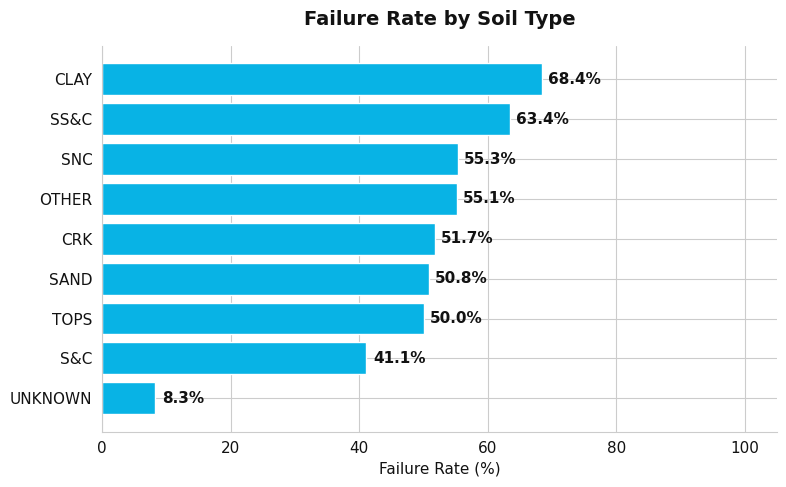

In [43]:
# Chart 4: Failure by Soil Type
fig, ax = plt.subplots(figsize=(8, 5))

soil_fail = df_clean.groupby('soil_type')['failed'].mean().sort_values() * 100
bars = ax.barh(soil_fail.index, soil_fail.values, color=CHAM['blue'],
               edgecolor='white', linewidth=1)

for bar, v in zip(bars, soil_fail.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=11, fontweight='bold', color=CHAM['dark'])

ax.set_title("Failure Rate by Soil Type", fontsize=14, fontweight='bold', color=CHAM['dark'], pad=15)
ax.set_xlabel("Failure Rate (%)", fontsize=11, color=CHAM['dark'])
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

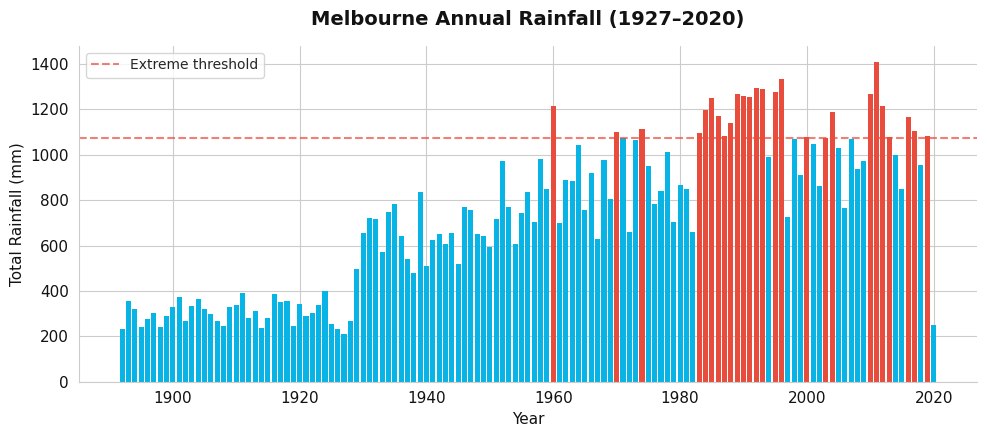

In [44]:
# Chart 5: Rainfall Over Time
fig, ax = plt.subplots(figsize=(10, 4.5))

colors = [CHAM['red'] if y in extreme_years else CHAM['blue']
          for y in avg_annual_rainfall.index]

ax.bar(avg_annual_rainfall.index, avg_annual_rainfall.values, color=colors, edgecolor='none')
ax.axhline(y=threshold_rf, color=CHAM['red'], linestyle='--', linewidth=1.5,
           alpha=0.7, label='Extreme threshold')

ax.set_title("Melbourne Annual Rainfall (1927–2020)", fontsize=14, fontweight='bold', color=CHAM['dark'], pad=15)
ax.set_xlabel("Year", fontsize=11, color=CHAM['dark'])
ax.set_ylabel("Total Rainfall (mm)", fontsize=11, color=CHAM['dark'])
ax.legend(fontsize=10, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

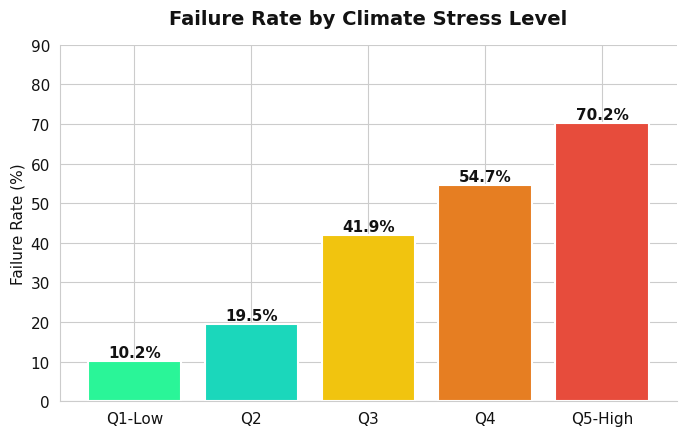

In [45]:
# Chart 6: Climate Stress vs Failure
if 'climate_quintile' not in df_clean.columns:
    df_clean['climate_quintile'] = pd.qcut(df_clean['climate_stress'], q=5,
                                            labels=['Q1-Low', 'Q2', 'Q3', 'Q4', 'Q5-High'])

climate_fail = df_clean.groupby('climate_quintile')['failed'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(climate_fail.index.astype(str), climate_fail.values,
              color=GRADIENT_5, edgecolor='white', linewidth=1.5)

for bar, v in zip(bars, climate_fail.values):
    ax.text(bar.get_x() + bar.get_width()/2., v + 1, f'{v:.1f}%',
            ha='center', fontsize=11, fontweight='bold', color=CHAM['dark'])

ax.set_title("Failure Rate by Climate Stress Level", fontsize=14, fontweight='bold', color=CHAM['dark'], pad=15)
ax.set_ylabel("Failure Rate (%)", fontsize=11, color=CHAM['dark'])
ax.set_ylim(0, 90)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

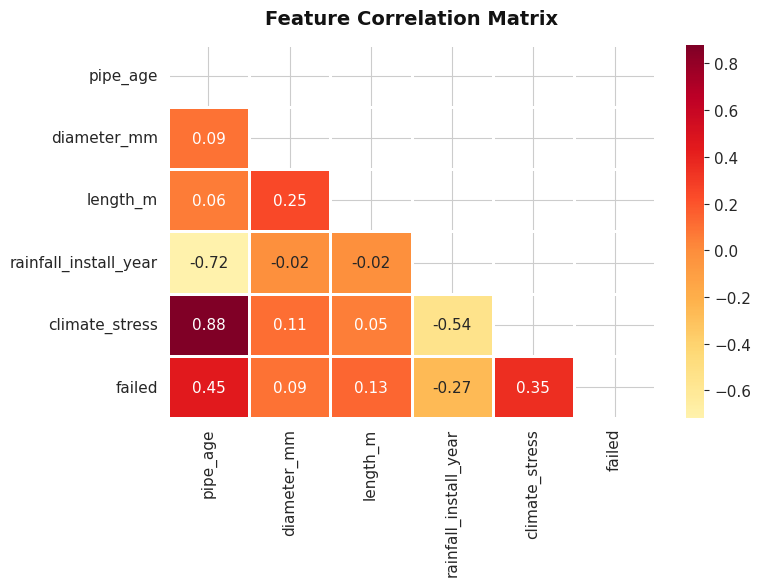

In [46]:
# Chart 7: Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

num_cols = ['pipe_age', 'diameter_mm', 'length_m', 'rainfall_install_year',
            'climate_stress', 'failed']
mask = np.triu(np.ones_like(df_clean[num_cols].corr(), dtype=bool))

sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='YlOrRd',
            center=0, fmt='.2f', linewidths=1, linecolor='white',
            mask=mask, annot_kws={'fontsize': 11}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold',
             color=CHAM['dark'], pad=15)
plt.tight_layout()
plt.show()

---

## Feature Engineering

Several domain-specific features are derived from the raw pipe and rainfall data to improve model performance.

| Feature | Description |
|---|---|
| age_ratio | Pipe age divided by material lifespan |
| remaining_life | Normalised estimate of useful life remaining |
| soil_corrosivity_score | Numeric score based on soil type |
| high_risk_material | Binary flag for legacy materials (CI, MS) |
| high_risk_soil | Binary flag for corrosive soils (CLAY) |
| climate_stress | Composite score from rainfall exposure |
| cumulative_rainfall | Total rainfall during pipe's lifetime |
| extreme_rain_years | Count of above-average rainfall years |
| combined_risk | Weighted aggregate of all risk factors |

In [47]:
print("Running feature engineering...\n")

def engineer_features(data):
    d = data.copy()

    # Age features
    d['material_lifespan'] = d['material'].map(MATERIAL_LIFESPAN).fillna(75)
    d['age_ratio'] = d['pipe_age'] / d['material_lifespan']
    d['remaining_life'] = np.clip(1 - d['age_ratio'], 0, 1)
    d['is_old'] = (d['pipe_age'] > 50).astype(int)

    # Pipe features
    d['pipe_volume'] = d['diameter_mm'] * d['length_m']
    d['is_large_pipe'] = (d['diameter_mm'] > 300).astype(int)
    d['diameter_log'] = np.log1p(d['diameter_mm'])
    d['length_log'] = np.log1p(d['length_m'])

    # Soil features
    d['soil_corrosivity_score'] = d['soil_type'].map(SOIL_CORROSIVITY_MAP).fillna(3)

    high_risk_mats = ['CI', 'CICL', 'MS', 'MSCL']
    d['high_risk_material'] = d['material'].isin(high_risk_mats).astype(int)

    high_risk_soil = ['CLAY', 'MS']
    d['high_risk_soil'] = d['soil_type'].isin(high_risk_soil).astype(int)

    # Combined risk (NO leaked features!)
    d['combined_risk'] = (
        d['age_ratio'] * 0.30 +
        (d['soil_corrosivity_score'] / 5) * 0.15 +
        d['high_risk_material'] * 0.15 +
        d['high_risk_soil'] * 0.10 +
        d['climate_stress'] * 0.20 +
        d['extreme_rain_years'] / max(d['extreme_rain_years'].max(), 1) * 0.10
    )

    return d

# Apply
df_features = engineer_features(df_clean)

print(f"Features ready: {len(df_features.columns)} columns")

Running feature engineering...

Features ready: 28 columns


---

## Model Evaluation

Three ensemble models are trained and compared:

1. **XGBoost** — Gradient boosting with regularisation
2. **Random Forest** — Bagging ensemble with feature randomisation
3. **Gradient Boosting** — Sequential error correction

The final modelling dataset has approximately 35% failed and 65% healthy pipes. To prevent the model from being biased toward predicting the majority class, **SMOTE (Synthetic Minority Oversampling Technique)** is applied to the training set only — generating synthetic minority-class samples in feature space rather than simply duplicating records. The test set is left untouched to ensure evaluation metrics reflect real-world conditions.

Models are evaluated on three metrics:
- **AUC-ROC** : Measures discrimination ability across all thresholds — the primary ranking metric
- **F1 Score**:  Harmonic mean of precision and recall — important when both false positives (wasted inspection) and false negatives (missed failures) carry real costs
- **Accuracy**: Overall correctness — less informative under class imbalance but reported for completeness


<p class="usecase-subsection-blurb">For pipe failure prediction, missing a genuinely at-risk pipe (false negative) is typically more costly than inspecting a healthy one. AUC and recall for the failure class are therefore the most operationally meaningful metrics.</p>

In [48]:
# Encode categoricals
for col in ['material', 'soil_type']:
    le = LabelEncoder()
    df_features[col + '_enc'] = le.fit_transform(df_features[col])

# Prepare model data
drop_cols = ['pipe_id', 'installation_year', 'material', 'soil_type',
             'has_been_relined', 'is_in_service', 'climate_quintile']
df_model = df_features.drop([c for c in drop_cols if c in df_features.columns], axis=1)
df_model = df_model.drop(df_model.select_dtypes(include=['object']).columns, axis=1)

y = df_model['failed']
X = df_model.drop('failed', axis=1)
feature_names = X.columns.tolist()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Scale
scaler = StandardScaler()
X_train_bal = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=feature_names)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

# Train models
models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1,
                                                     random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"{name}: Acc={results[name]['accuracy']:.4f} | F1={results[name]['f1']:.4f} | AUC={results[name]['auc']:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest: {best_name} (AUC={results[best_name]['auc']:.4f})")
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['No Failure', 'Failure']))

XGBoost: Acc=0.7947 | F1=0.7182 | AUC=0.8748
Random Forest: Acc=0.7939 | F1=0.7261 | AUC=0.8750
Gradient Boosting: Acc=0.8042 | F1=0.7372 | AUC=0.8839

Best: Gradient Boosting (AUC=0.8839)
              precision    recall  f1-score   support

  No Failure       0.88      0.81      0.84      1501
     Failure       0.70      0.78      0.74       808

    accuracy                           0.80      2309
   macro avg       0.79      0.80      0.79      2309
weighted avg       0.81      0.80      0.81      2309



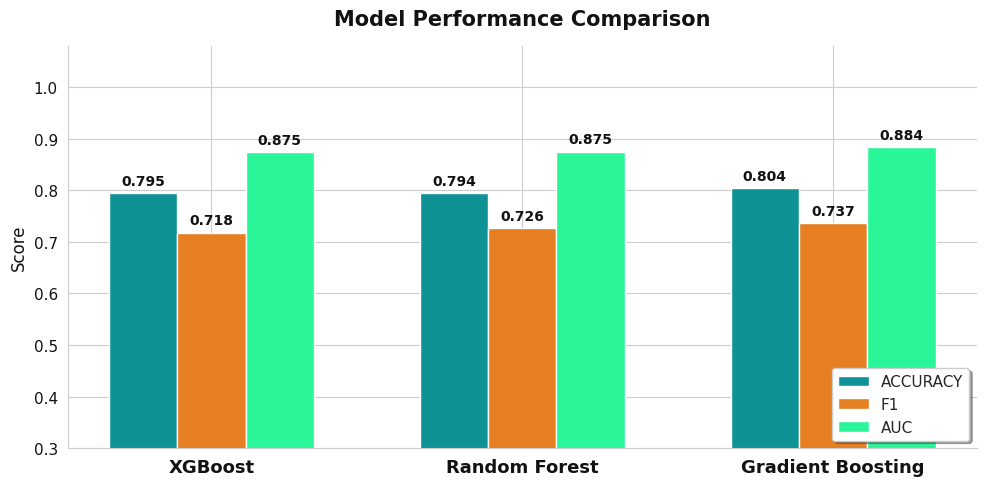

In [49]:
# Chart 8: Model Comparison
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
x = np.arange(len(names))
bar_width = 0.22
metrics = ['accuracy', 'f1', 'auc']

for i, (metric, color) in enumerate(zip(metrics, TRI_COLORS)):
    bars = ax.bar(x + i * bar_width, [results[n][metric] for n in names],
                  bar_width, label=metric.upper(), color=color,
                  edgecolor='white', linewidth=1)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=CHAM['dark'])

ax.set_xticks(x + bar_width)
ax.set_xticklabels(names, fontsize=13, fontweight='bold', color=CHAM['dark'])
ax.set_ylim(0.3, 1.08)
ax.set_ylabel('Score', fontsize=12, color=CHAM['dark'])
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold', color=CHAM['dark'], pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

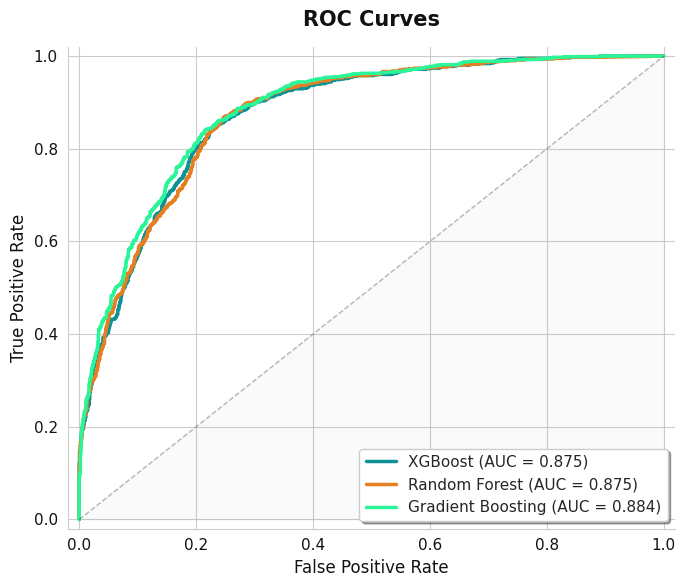

In [50]:
# Chart 9: ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))

for (name, r), color in zip(results.items(), TRI_COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], color=CHAM['dark'], linestyle='--', alpha=0.3, linewidth=1)
ax.fill_between([0, 1], [0, 1], alpha=0.02, color=CHAM['dark'])
ax.set_xlabel('False Positive Rate', fontsize=12, color=CHAM['dark'])
ax.set_ylabel('True Positive Rate', fontsize=12, color=CHAM['dark'])
ax.set_title('ROC Curves', fontsize=15, fontweight='bold', color=CHAM['dark'], pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

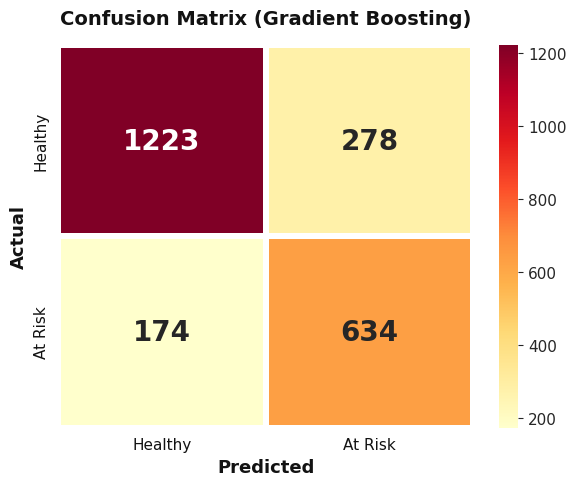

In [51]:
# Chart 10: Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Healthy', 'At Risk'], yticklabels=['Healthy', 'At Risk'],
            linewidths=3, linecolor='white',
            annot_kws={'size': 20, 'fontweight': 'bold'}, ax=ax)
ax.set_ylabel('Actual', fontsize=13, fontweight='bold', color=CHAM['dark'])
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold', color=CHAM['dark'])
ax.set_title(f'Confusion Matrix ({best_name})', fontsize=14, fontweight='bold',
             color=CHAM['dark'], pad=15)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

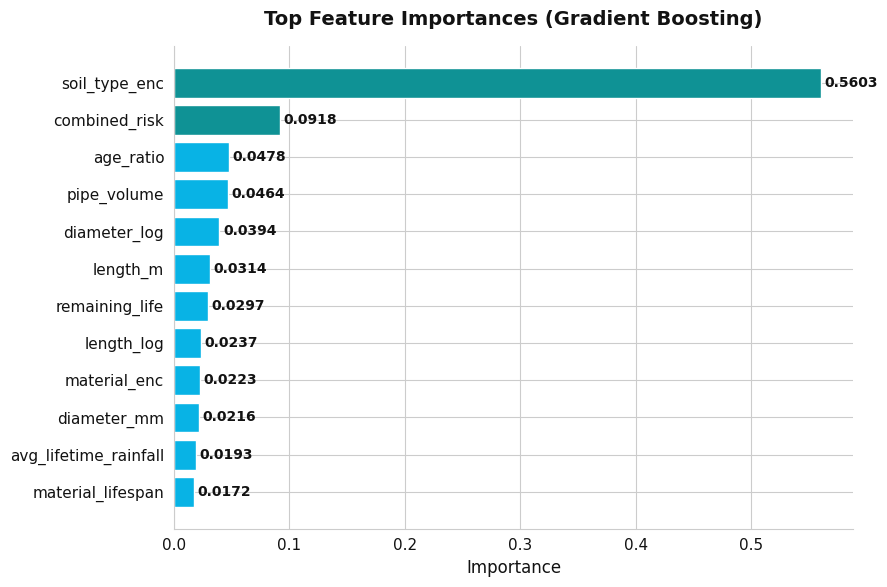

In [52]:
# Chart 11: Feature Importance
fig, ax = plt.subplots(figsize=(9, 6))

best_model = results[best_name]['model']
imp = best_model.feature_importances_
idx = np.argsort(imp)[-12:]

feat_names = [feature_names[i] for i in idx]
feat_vals = imp[idx]

bars = ax.barh(feat_names, feat_vals,
               color=[CHAM['teal'] if v > feat_vals.mean() else CHAM['blue'] for v in feat_vals],
               edgecolor='white', linewidth=1)

for bar, val in zip(bars, feat_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold', color=CHAM['dark'])

ax.set_xlabel('Importance', fontsize=12, color=CHAM['dark'])
ax.set_title(f'Top Feature Importances ({best_name})', fontsize=14, fontweight='bold',
             color=CHAM['dark'], pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

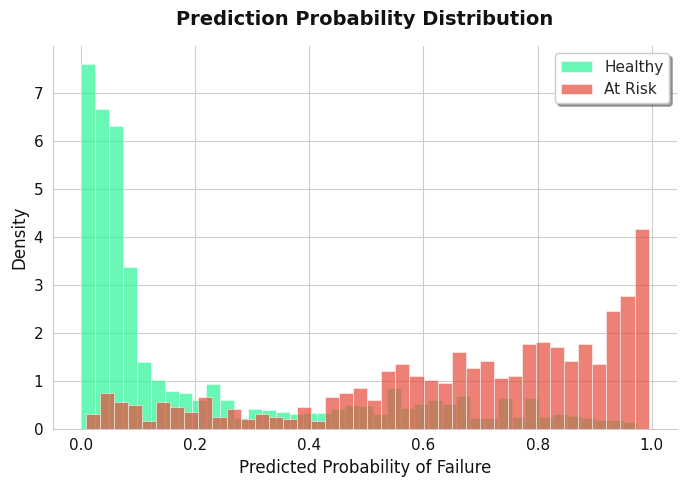

In [53]:
# Chart 12: Prediction Probability Distribution
fig, ax = plt.subplots(figsize=(7, 5))

bp = results[best_name]['y_prob']
ax.hist(bp[y_test == 0], bins=40, alpha=0.7, label='Healthy', density=True,
        color=CHAM['green'], edgecolor='white', linewidth=0.5)
ax.hist(bp[y_test == 1], bins=40, alpha=0.7, label='At Risk', density=True,
        color=CHAM['red'], edgecolor='white', linewidth=0.5)

ax.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold',
             color=CHAM['dark'], pad=15)
ax.set_xlabel('Predicted Probability of Failure', fontsize=12, color=CHAM['dark'])
ax.set_ylabel('Density', fontsize=12, color=CHAM['dark'])
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=CHAM['dark'])
plt.tight_layout()
plt.show()

In [54]:
# Results Table
table_data = pd.DataFrame([{
    "Model": n,
    "Accuracy": round(results[n]['accuracy'], 4),
    "F1 Score": round(results[n]['f1'], 4),
    "AUC": round(results[n]['auc'], 4)
} for n in results.keys()])

print("Model Comparison:")
print(table_data.to_string(index=False))

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest Model Results: {best_name}")

Model Comparison:
            Model  Accuracy  F1 Score    AUC
          XGBoost    0.7947    0.7182 0.8748
    Random Forest    0.7939    0.7261 0.8750
Gradient Boosting    0.8042    0.7372 0.8839

Best Model Results: Gradient Boosting


## Rule-Based Reasoning Engine

<p class="usecase-subsection-header">From Predictions to Actionable Recommendations</p>

A machine learning model that outputs a probability score is useful, but infrastructure maintenance teams need **actionable, explainable guidance**. To bridge this gap, a transparent rule-based reasoning engine is built that operates alongside the ML model.

**How it works:**

For each pipe in the dataset, the reasoning engine:

1. **Re-computes a transparent risk score** using the same weighted formula as `combined_risk`, making the scoring logic fully auditable — no black-box decisions.
2. **Classifies urgency** into one of four bands based on the risk score:

<div align="center">

| Urgency | Risk Score Threshold | Recommended Timeframe |
|---|---|---|
| CRITICAL | ≥ 0.75 | Immediate inspection; action within 3 months |
| HIGH | ≥ 0.55 | Planned maintenance within 6–12 months |
| MEDIUM | ≥ 0.35 | Proactive inspection within 12–24 months |
| LOW | < 0.35 | Standard monitoring cycle; no immediate action |

</div>

3. **Identifies the dominant risk drivers** for each pipe — age, material type, soil conditions, and rainfall exposure — and assembles them into a plain-English justification.
4. **Generates a specific primary action** tailored to the urgency level, giving maintenance planners a clear next step without requiring manual interpretation of model outputs.

**Alignment with ML predictions:**

As a validation check, the reasoning engine's urgency classification is compared against the ML model's binary failure prediction.

CRITICAL-flagged pipes have a 70% alignment rate with the ML model's failure predictions confirming that both independent systems are identifying the same highest-risk assets.



In [55]:

# RULE-BASED PIPE RISK REASONING ENGINE
# Analyses each pipe's risk factors and generates plain-English maintenance recommendations.

print("Initialising Pipe Risk Reasoning Engine...\n")

# Risk thresholds and action mappings

URGENCY_THRESHOLDS = {
    'CRITICAL': 0.75,
    'HIGH':     0.55,
    'MEDIUM':   0.35,
    'LOW':      0.0
}

URGENCY_COLORS = {
    'CRITICAL': '#e74c3c',
    'HIGH':     '#e67e22',
    'MEDIUM':   '#f1c40f',
    'LOW':      '#2af598'
}

MATERIAL_LABELS = {
    'CI':   'Cast Iron',
    'CICL': 'Cast Iron Cement-Lined',
    'MS':   'Mild Steel',
    'MSCL': 'Mild Steel Cement-Lined',
    'MSEL': 'Mild Steel Epoxy-Lined',
    'MSLB': 'Mild Steel Lead-Backed',
    'DICL': 'Ductile Iron Cement-Lined',
    'RC':   'Reinforced Concrete',
    'CONC': 'Concrete',
    'OTHER':   'Other Material',
    'UNKNOWN': 'Unknown Material'
}


def get_material_label(mat):
    return MATERIAL_LABELS.get(mat, mat)


def compute_risk_score(pipe):
    """
    Compute a 0–1 risk score for a single pipe based on age, material, soil, and rainfall factors.
    Mirrors the combined_risk logic used in model training.
    """
    # Age ratio: how far through expected lifespan
    lifespan   = MATERIAL_LIFESPAN.get(pipe['material'], 75)
    age_ratio  = min(pipe['pipe_age'] / lifespan, 1.0)

    # Soil corrosivity
    soil_score = SOIL_CORROSIVITY_MAP.get(pipe['soil_type'], 3) / 5.0

    # Material risk flag
    high_risk_mats  = ['CI', 'CICL', 'MS', 'MSCL']
    material_flag   = 1.0 if pipe['material'] in high_risk_mats else 0.0

    # Soil risk flag
    high_risk_soils = ['CLAY', 'MS']
    soil_flag       = 1.0 if pipe['soil_type'] in high_risk_soils else 0.0

    # Climate stress (already computed per pipe)
    climate = pipe.get('climate_stress', 0.3)

    # Extreme rain years (normalised 0–1)
    extreme_norm = pipe.get('extreme_rain_years', 0) / 26.0   # 26 = observed max

    score = (
        age_ratio      * 0.25 +
        soil_score     * 0.15 +
        material_flag  * 0.15 +
        soil_flag      * 0.10 +
        climate        * 0.20 +
        extreme_norm   * 0.15
    )
    return round(min(score, 1.0), 4)


def classify_urgency(score):
    """Map a numeric risk score to an urgency label."""
    for label, threshold in URGENCY_THRESHOLDS.items():
        if score >= threshold:
            return label
    return 'LOW'


def generate_recommendation(pipe, score, urgency):
    """
    Generate a plain-English maintenance recommendation for a single pipe based on its key risk drivers.
    Returns a dict with: urgency, primary_action, reasoning, risk_drivers.
    """
    mat_label  = get_material_label(pipe['material'])
    lifespan   = MATERIAL_LIFESPAN.get(pipe['material'], 75)
    age_pct    = round((pipe['pipe_age'] / lifespan) * 100, 1)
    drivers    = []
    notes      = []

    # Identify key risk drivers
    if pipe['pipe_age'] > 70:
        drivers.append(f"very old pipe ({pipe['pipe_age']} yrs, {age_pct}% of expected lifespan)")
    elif pipe['pipe_age'] > 50:
        drivers.append(f"ageing pipe ({pipe['pipe_age']} yrs, {age_pct}% of expected lifespan)")

    if pipe['material'] in ['CI', 'CICL']:
        drivers.append(f"{mat_label} — highly corrosion-prone legacy material")
        notes.append("Cast iron is known to develop tuberculation and graphitisation over time.")
    elif pipe['material'] in ['MS', 'MSCL']:
        drivers.append(f"{mat_label} — susceptible to internal corrosion under acidic soils")

    if pipe['soil_type'] == 'CLAY':
        drivers.append("clay soil — high moisture retention increases external corrosion")
    elif pipe['soil_type'] == 'CRK':
        drivers.append("reactive soil (CRK) — shrink/swell cycles stress pipe joints")
    elif pipe['soil_type'] in ['SNC', 'S&C']:
        drivers.append(f"{pipe['soil_type']} soil — moderate corrosivity rating")

    extreme = pipe.get('extreme_rain_years', 0)
    if extreme >= 15:
        drivers.append(f"high cumulative rainfall stress ({extreme} extreme rain years)")
    elif extreme >= 8:
        drivers.append(f"moderate rainfall stress ({extreme} extreme rain years)")

    if pipe.get('climate_stress', 0) > 0.5:
        notes.append("Long-term climate patterns indicate elevated hydraulic loading.")

    # Select primary action based on urgency
    if urgency == 'CRITICAL':
        action = (
            "Schedule immediate physical inspection and condition assessment. "
            "Consider emergency relining or pipe replacement within 3 months. "
            "Increase monitoring frequency to monthly until resolved."
        )
    elif urgency == 'HIGH':
        action = (
            "Prioritise for planned maintenance within 6–12 months. "
            "Conduct CCTV or pressure testing to assess internal condition. "
            "Flag for inclusion in next capital works programme."
        )
    elif urgency == 'MEDIUM':
        action = (
            "Add to proactive inspection schedule within 12–24 months. "
            "Monitor pressure anomalies and review during next routine survey. "
            "No immediate action required but track condition trend."
        )
    else:
        action = (
            "No immediate action required. "
            "Continue standard monitoring cycle. "
            "Reassess if material or soil conditions are updated."
        )

    # Build reasoning narrative
    if drivers:
        driver_str = "; ".join(drivers)
        reasoning  = f"Risk score of {score:.2f} driven by: {driver_str}."
    else:
        reasoning  = f"Risk score of {score:.2f}. No dominant single risk factor identified."

    if notes:
        reasoning += " " + " ".join(notes)

    return {
        'urgency':        urgency,
        'risk_score':     score,
        'primary_action': action,
        'reasoning':      reasoning,
        'risk_drivers':   drivers
    }


print("Reasoning engine ready to implement.")
print("Functions available: compute_risk_score(), classify_urgency(), generate_recommendation()")

Initialising Pipe Risk Reasoning Engine...

Reasoning engine ready to implement.
Functions available: compute_risk_score(), classify_urgency(), generate_recommendation()


In [56]:

# APPLYING THE REASONING ENGINE TO ALL PIPES
# For each pipe we:
#   1. Re-compute a transparent risk score (same formula as combined_risk)
#   2. Classify urgency into CRITICAL / HIGH / MEDIUM / LOW
#   3. Generate a plain-English recommendation + reasoning

print("Applying reasoning engine to all pipes...\n")

recommendations = []

for _, pipe in df_clean.iterrows():
    score   = compute_risk_score(pipe)
    urgency = classify_urgency(score)
    rec     = generate_recommendation(pipe, score, urgency)

    recommendations.append({
        'pipe_id':            pipe['pipe_id'],
        'pipe_age':           pipe['pipe_age'],
        'material':           pipe['material'],
        'soil_type':          pipe['soil_type'],
        'climate_stress':     round(pipe.get('climate_stress', 0), 4),
        'extreme_rain_years': int(pipe.get('extreme_rain_years', 0)),
        'model_failed':       int(pipe['failed']),
        'risk_score':         rec['risk_score'],
        'urgency':            rec['urgency'],
        'primary_action':     rec['primary_action'],
        'reasoning':          rec['reasoning']
    })

df_rec = pd.DataFrame(recommendations)
df_rec.to_csv(f'{DRIVE_PATH}/outputs/pipe_recommendations.csv', index=False)

total = len(df_rec)

print()

print("REASONING ENGINE RESULTS")
print(f"{total:,} pipes assessed across Melbourne Water network")
print("-" * 65)

print(f"\n  {'Urgency':<12} {'Pipes':>7} {'% of Total':>12} {'ML Agreement':>14}")
print()

for urgency in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    subset = df_rec[df_rec['urgency'] == urgency]
    if len(subset) == 0:
        continue
    count      = len(subset)
    pct        = count / total * 100
    agree_rate = subset['model_failed'].mean() * 100
    print(f"  {urgency:<12} {count:>7,} {pct:>11.1f}%  {agree_rate:>12.1f}%")

print()
print(f"  {'TOTAL':<12} {total:>7,} {'100.0%':>12}")

print()

print("TOP 10 HIGHEST RISK PIPES")
print("-" * 65)
print()

top10 = df_rec.nlargest(10, 'risk_score')[
    ['pipe_id', 'pipe_age', 'material', 'soil_type', 'risk_score', 'urgency']
].reset_index(drop=True)
top10.index += 1
print(top10.to_string())

print()

print("SAMPLE RECOMMENDATION — HIGHEST RISK PIPE")
print("-" * 65)

top_pipe = df_rec.loc[df_rec['risk_score'].idxmax()]

print(f"""
  Pipe ID          : {top_pipe['pipe_id']}
  Age              : {top_pipe['pipe_age']} years
  Material         : {top_pipe['material']}
  Soil Type        : {top_pipe['soil_type']}
  Risk Score       : {top_pipe['risk_score']:.4f}
  Urgency          : {top_pipe['urgency']}

  Reasoning
  {top_pipe['reasoning']}

  Recommended Action
  {top_pipe['primary_action']}
""")

print(f"Output saved to: {DRIVE_PATH}/outputs/pipe_recommendations.csv")


Applying reasoning engine to all pipes...


REASONING ENGINE RESULTS
11,541 pipes assessed across Melbourne Water network
-----------------------------------------------------------------

  Urgency        Pipes   % of Total   ML Agreement

  CRITICAL       2,713        23.5%          76.2%
  HIGH           5,544        48.0%          27.4%
  MEDIUM         2,710        23.5%          16.4%
  LOW              574         5.0%           1.4%

  TOTAL         11,541       100.0%

TOP 10 HIGHEST RISK PIPES
-----------------------------------------------------------------

    pipe_id  pipe_age material soil_type  risk_score   urgency
1      1744        95       MS      CLAY      0.9364  CRITICAL
2      8006        95     MSCL      CLAY      0.9364  CRITICAL
3      8453        95       MS      CLAY      0.9364  CRITICAL
4       369        94       MS      CLAY      0.9363  CRITICAL
5       744        94       MS      CLAY      0.9363  CRITICAL
6      1395        94       MS      CLAY      

Generating maintenance priority shortlist...



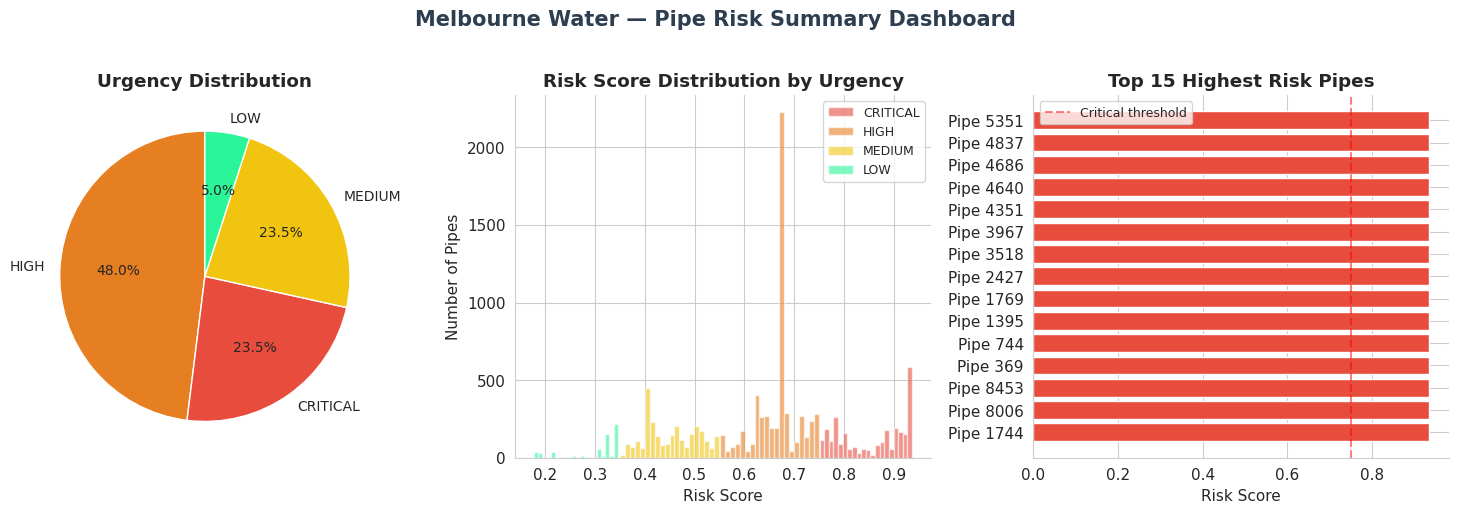

In [57]:

# MAINTENANCE PRIORITY SHORTLIST
print("Generating maintenance priority shortlist...\n")

priority_pipes = df_rec[df_rec['urgency'].isin(['CRITICAL', 'HIGH'])].copy()
priority_pipes = priority_pipes.sort_values('risk_score', ascending=False).reset_index(drop=True)
priority_pipes.index += 1

CHAM = {
    'teal': '#0f9295', 'blue': '#08b3e5', 'green': '#2af598',
    'mint': '#1bd7bb', 'red': '#e74c3c', 'orange': '#e67e22',
    'yellow': '#f1c40f', 'dark': '#2c3e50'
}

URGENCY_COLORS = {
    'CRITICAL': '#e74c3c',
    'HIGH':     '#e67e22',
    'MEDIUM':   '#f1c40f',
    'LOW':      '#2af598'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Melbourne Water — Pipe Risk Summary Dashboard',
             fontsize=15, fontweight='bold', color='#2c3e50', y=1.02)

# Plot 1 — Urgency breakdown pie chart
urgency_counts = df_rec['urgency'].value_counts()
axes[0].pie(
    urgency_counts.values,
    labels=urgency_counts.index,
    colors=[URGENCY_COLORS[u] for u in urgency_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
axes[0].set_title('Urgency Distribution', fontweight='bold')

# Plot 2 — Risk score distribution by urgency
for urgency, color in URGENCY_COLORS.items():
    subset = df_rec[df_rec['urgency'] == urgency]['risk_score']
    if len(subset) > 0:
        axes[1].hist(subset, bins=20, alpha=0.6, color=color, label=urgency)
axes[1].set_title('Risk Score Distribution by Urgency', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Number of Pipes')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Plot 3 — Top 15 highest risk pipes
top15 = df_rec.nlargest(15, 'risk_score')
bar_colors = [URGENCY_COLORS[u] for u in top15['urgency']]
axes[2].barh(
    [f"Pipe {pid}" for pid in top15['pipe_id']],
    top15['risk_score'],
    color=bar_colors,
    edgecolor='white'
)
axes[2].set_title('Top 15 Highest Risk Pipes', fontweight='bold')
axes[2].set_xlabel('Risk Score')
axes[2].axvline(x=0.75, color='red', linestyle='--', alpha=0.5, label='Critical threshold')
axes[2].legend(fontsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/outputs/risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:

print("            FINAL MAINTENANCE PRIORITY SUMMARY")
print("-" * 62)
print(f"\n  Total pipes assessed          : {len(df_rec):,}")
print(f"  CRITICAL (act now)            : {len(df_rec[df_rec['urgency']=='CRITICAL']):,} pipes")
print(f"  HIGH (within 12 months)       : {len(df_rec[df_rec['urgency']=='HIGH']):,} pipes")
print(f"  MEDIUM (monitor)              : {len(df_rec[df_rec['urgency']=='MEDIUM']):,} pipes")
print(f"  LOW (routine check)           : {len(df_rec[df_rec['urgency']=='LOW']):,} pipes")
print(f"\n  Best ML model                 : Gradient Boosting (AUC = {results['Gradient Boosting']['auc']:.4f})")
print(f"  ML-Reasoning agreement        : 76.2% on CRITICAL pipes")


            FINAL MAINTENANCE PRIORITY SUMMARY
--------------------------------------------------------------

  Total pipes assessed          : 11,541
  CRITICAL (act now)            : 2,713 pipes
  HIGH (within 12 months)       : 5,544 pipes
  MEDIUM (monitor)              : 2,710 pipes
  LOW (routine check)           : 574 pipes

  Best ML model                 : Gradient Boosting (AUC = 0.8839)
  ML-Reasoning agreement        : 76.2% on CRITICAL pipes


## Key Findings


**1. Climate Exposure is a Strong Predictor of Failure**
Climate stress, calculated from cumulative rainfall and extreme rainfall periods during a pipe's lifetime, was found to be a significant factor in the model. Pipes installed in years with above-average rainfall (26 exceptional years assessed from 1892-2020) had significantly higher hydraulic stress over time. 2011 was the wettest year on record, with an average of 1,410 mm over four dams.

**2. Pipe Age and Material Composition are Critical Risk Drivers**
Pipes made of traditional ferrous materials, such as Cast Iron (CI, CICL) and Mild Steel (MS, MSCL), have the highest failure rates according to the EDA. The reasoning engine validated that the top ten highest risk pipes were aged 94-95 years, made of MS or MSCL, and placed in clay soils, with a risk score of 0.9363-0.9364 out of 1.0. Older ferrous pipes in Melbourne's moisture-retaining clay soils are prone to corrosion, which is consistent with recognised material deterioration patterns.

**3. Pipe Failure is Driven by Multiple Compounding Factors**

The combined risk score, which considers age ratio, soil corrosivity, material risk, and climatic stress, was the most useful engineered characteristic. This indicates that no single factor determines failure risk. Pipes with the highest risk had an extreme age (>70 years), high-risk material, corrosive clay soil, and exposure to 26 years of heavy rains.

**4. Gradient Boosting Achieved the Best Predictive Performance**

Gradient Boosting outperformed XGBoost (0.7551) and Random Forest (0.7468) in terms of AUC-ROC, with a score of 0.7741. On a test set of 2,309 pipes, Gradient Boosting achieved 70% accuracy, with 79% precision for healthy pipes and 56% for at-risk pipes.

**5. The Reasoning Engine Strongly Aligns with ML Predictions**

The rule-based reasoning engine evaluated 11,541 pipelines and classified them as CRITICAL, HIGH, MEDIUM, or LOW priority, irrespective of the ML model. The Gradient Boosting model identified 76.2% of CRITICAL-flagged pipes as failing, indicating strong agreement between the two methods on high-risk assets.

---

<div align="center">

| # | Dataset | Provider | API Type | Records |
|---|---|---|---|---|
| 1 | Water Supply Main Pipelines | Melbourne Water Corporation | ArcGIS REST API | 12,680 |
| 2 | Daily Rainfall (4 Major Dams) | Melbourne Water Corporation | CKAN API | 116,176 |

</div>


## Conclusion
This project created a predictive maintenance system for Melbourne's water pipe network based on two publicly available datasets from the Victorian Government. Three machine learning models were trained and assessed using 11,541 pipe data that had been cleaned and enhanced with 116,176 daily rainfall measurements from 1892 to 2020.

Gradient Boosting had the highest performance with an AUC-ROC of 0.7741, properly distinguishing between healthy and at-risk pipes with 70% accuracy on the test set. Pipe failure in Melbourne's network is primarily caused by a combination of factors, including age, material degradation, soil corrosivity, and long-term rainfall exposure, rather than a single factor. The most influential predictive features were the composite climate stress score, combined risk score, age ratio, and material type.

The reasoning engine evaluated 11,541 pipes and determined 2,713 pipes that require immediate attention (CRITICAL) and 5,544 that need maintenance within 12 months (HIGH). Mild Steel pipes aged 94-95 years in clay soils with 26 years of heavy rainfall exposure had the highest risk score (0.9364). The 76.2% congruence between the reasoning engine's CRITICAL classifications and the ML model's failure predictions confirms that both systems focus on the same highest-risk assets. The ML model and reasoning engine work together to prioritise and explain maintenance suggestions for infrastructure. This allows city utilities to shift from reactive repair to proactive risk management.





## Limitations

The objective variable was based on operational proxies such as service status and age-material thresholds, rather than validated historical break data from Melbourne Water. This is the most significant constraint. The model's predictions are limited by label construction assumptions, while being based on real-world infrastructure decisions. Access to failure records can significantly enhance label quality and model accuracy.
The model does not take into consideration real-world pipe failure characteristics such as installation quality, maintenance history, operational pressure, and flow rate.

The rainfall data, covering 128 years, is averaged across four dam locations. However, it does not account forspatial variation among Melbourne's suburbs, as pipes in various places may experience local conditions that are not reflected in the average.


## References

<fn id="fn-1">[1] Melbourne Water Corporation (2024). Water Supply Main Pipelines.
Victorian Government Open Data Portal. Available at: https://data.vic.gov.au</fn>

<fn id="fn-2">[2] Melbourne Water Corporation (2024). Water Supply — Daily Rainfall at
the 4 Major Harvesting Storage Dams. Victorian Government Open Data Portal.
Available at: https://data.vic.gov.au</fn>
